# robotsensei
- นายวันฟาดิว นฤชิต รหัสนักศึกษา 6710110383
- นายธนเดช นวคณิตเดชาญกุล รหัสนักศึกษา 6710110575


Using: c:\Users\asus\Documents\GitHub\Robotmaster\find_coke\chicken_processing\track_log_20250906_132241.csv


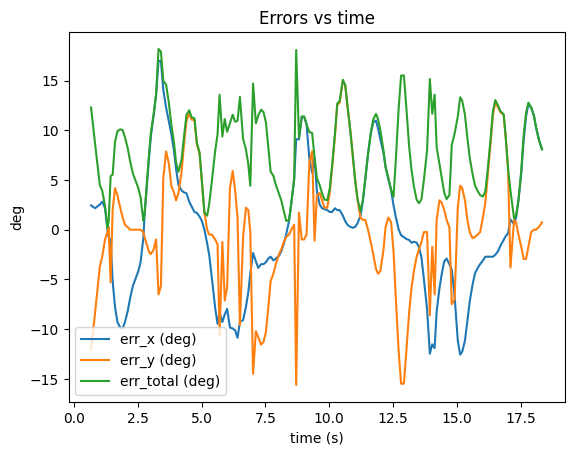

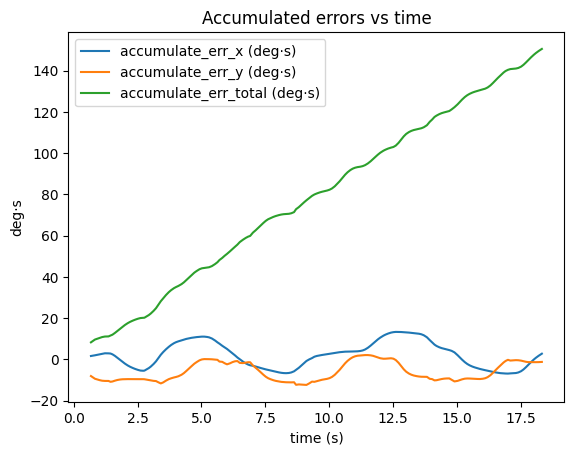

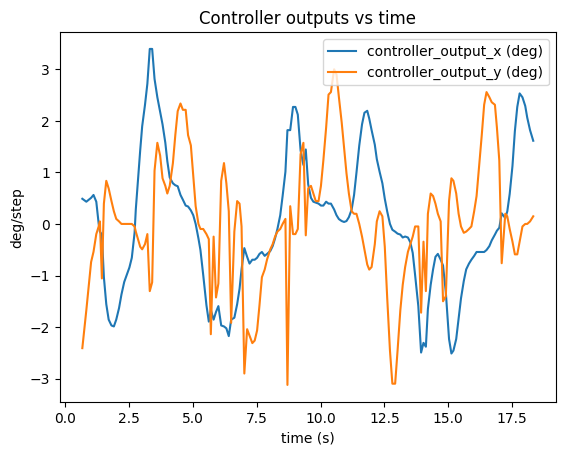

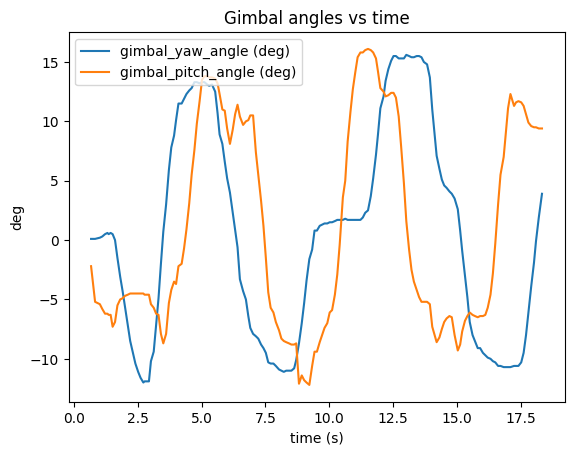

In [19]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== ชี้ไปที่ไฟล์ CSV ที่ต้องการ =====
csv_path = r"track_log_20250906_132241.csv"   # ใช้ r"..." หรือ "/" ป้องกันปัญหา backslash

assert os.path.exists(csv_path), f"ไม่พบไฟล์: {csv_path}"
print("Using:", os.path.abspath(csv_path))

# ===== โหลดข้อมูล =====
df = pd.read_csv(csv_path)

# แปลง dtype เป็นตัวเลขเท่าที่ทำได้
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="ignore")

# alias ชื่อให้สั้น (ตามคอลัมน์ที่ log ไว้)
rename = {
    "t_s": "t",
    "err_x_deg": "err_x",
    "err_y_deg": "err_y",
    "err_total_deg": "err_total",
    "accumulate_err_x_deg_s": "acc_err_x",
    "accumulate_err_y_deg_s": "acc_err_y",
    "accumulate_err_total_deg_s": "acc_err_total",
    "controller_output_x_deg": "u_x",
    "controller_output_y_deg": "u_y",
    "gimbal_yaw_angle_deg": "yaw_deg",
    "gimbal_pitch_angle_deg": "pitch_deg",
}
for src, dst in rename.items():
    if src in df.columns:
        df[dst] = pd.to_numeric(df[src], errors="coerce")

if "t" not in df.columns and "t_s" in df.columns:
    df["t"] = pd.to_numeric(df["t_s"], errors="coerce")

# ===== Plot 1: error =====
plt.figure()
plt.plot(df["t"], df.get("err_x"), label="err_x (deg)")
plt.plot(df["t"], df.get("err_y"), label="err_y (deg)")
plt.plot(df["t"], df.get("err_total"), label="err_total (deg)")
plt.xlabel("time (s)")
plt.ylabel("deg")
plt.title("Errors vs time")
plt.legend()
plt.show()

# ===== Plot 2: accumulated error =====
plt.figure()
plt.plot(df["t"], df.get("acc_err_x"), label="accumulate_err_x (deg·s)")
plt.plot(df["t"], df.get("acc_err_y"), label="accumulate_err_y (deg·s)")
plt.plot(df["t"], df.get("acc_err_total"), label="accumulate_err_total (deg·s)")
plt.xlabel("time (s)")
plt.ylabel("deg·s")
plt.title("Accumulated errors vs time")
plt.legend()
plt.show()

# ===== Plot 3: controller outputs =====
plt.figure()
plt.plot(df["t"], df.get("u_x"), label="controller_output_x (deg)")
plt.plot(df["t"], df.get("u_y"), label="controller_output_y (deg)")
plt.xlabel("time (s)")
plt.ylabel("deg/step")
plt.title("Controller outputs vs time")
plt.legend()
plt.show()

# ===== Plot 4: gimbal angles =====
plt.figure()
has_any = False
if "yaw_deg" in df.columns:
    plt.plot(df["t"], df["yaw_deg"], label="gimbal_yaw_angle (deg)")
    has_any = True
if "pitch_deg" in df.columns:
    plt.plot(df["t"], df["pitch_deg"], label="gimbal_pitch_angle (deg)")
    has_any = True
plt.xlabel("time (s)")
plt.ylabel("deg")
plt.title("Gimbal angles vs time")
plt.legend() if has_any else plt.text(0.5, 0.5, "No gimbal angle columns.", ha="center", va="center", transform=plt.gca().transAxes)
plt.show()
